In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [32]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [33]:
df = pd.read_csv("employee_turnover.csv")
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [34]:
X = df.drop('Employee_Turnover', axis=1)
y = df['Employee_Turnover']

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Baseline Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [37]:
# L1 Regularization (Lasso)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5)
lasso.fit(X_train, y_train)

LogisticRegression(C=0.5, penalty='l1', solver='liblinear')

In [38]:
# L2 Regularization (Ridge)
ridge = LogisticRegression(penalty='l2', C=1, max_iter=200)
ridge.fit(X_train, y_train)

LogisticRegression(C=1, max_iter=200)

### DATA LOADING & QUALITY CHECK

In [39]:
df = pd.read_csv("employee_turnover.csv")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nData Types:\n{df.dtypes.value_counts().to_string()}")
print(f"\nMissing Values : {df.isnull().sum().sum()} total")
print(f"Duplicate Rows : {df.duplicated().sum()}")

df.head()

Shape: 1350 rows × 16 columns

Data Types:
float64    15
int64       1

Missing Values : 0 total
Duplicate Rows : 450


,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


#### Statistical Summary

In [40]:
df.describe().round(3)

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
count,1350.000,1350.000,1350.000,1350.000,1350.000,1350.000,1350.000,1350.000,1350.000,1350.000,1350.000,1350.000,1350.000,1350.000,1350.000,1350.000
mean,0.506,0.487,0.485,0.499,0.495,0.510,0.504,0.500,0.516,0.506,0.493,0.487,0.486,0.329,0.241,0.498
std,0.292,0.284,0.283,0.293,0.289,0.290,0.296,0.295,0.295,0.285,0.293,0.288,0.285,0.299,0.222,0.500
min,0.002,0.001,0.002,0.000,0.001,0.005,0.000,0.000,0.000,0.001,0.000,0.001,0.002,0.000,0.000,0.000
25%,0.263,0.239,0.250,0.246,0.244,0.263,0.250,0.239,0.248,0.270,0.247,0.233,0.245,0.061,0.059,0.000
50%,0.525,0.468,0.485,0.496,0.502,0.532,0.509,0.500,0.531,0.505,0.498,0.475,0.469,0.248,0.165,0.000
75%,0.751,0.724,0.722,0.753,0.744,0.761,0.755,0.767,0.776,0.762,0.740,0.748,0.726,0.548,0.367,1.000
max,0.999,1.000,1.000,1.000,0.998,0.999,1.000,0.998,1.000,1.000,0.998,0.998,0.999,0.996,0.930,1.000


#### Class Balance Check

            Count  Percentage (%)
Stays (0)     678            50.2
Leaves (1)    672            49.8


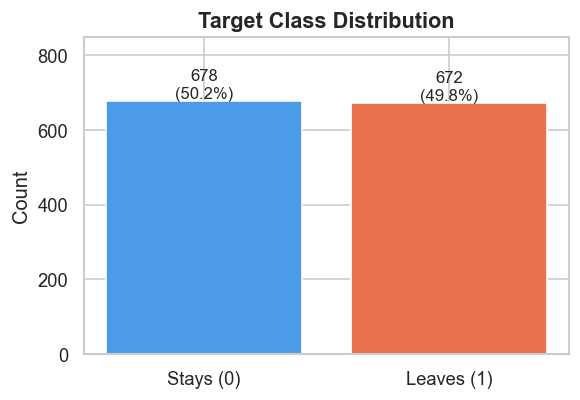

In [41]:
counts = df['Employee_Turnover'].value_counts()
pct    = df['Employee_Turnover'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({'Count': counts, 'Percentage (%)': pct.round(1)})
balance_df.index = ['Stays (0)', 'Leaves (1)']
print(balance_df)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['Stays (0)', 'Leaves (1)'], counts.values,
       color=['#4C9BE8', '#E8714C'], edgecolor='white')
ax.set_title('Target Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, f'{v}\n({pct.iloc[i]:.1f}%)', ha='center', fontsize=10)
ax.set_ylim(0, max(counts.values) * 1.25)
plt.tight_layout()
plt.show()

### EDA — Correlation Heatmap

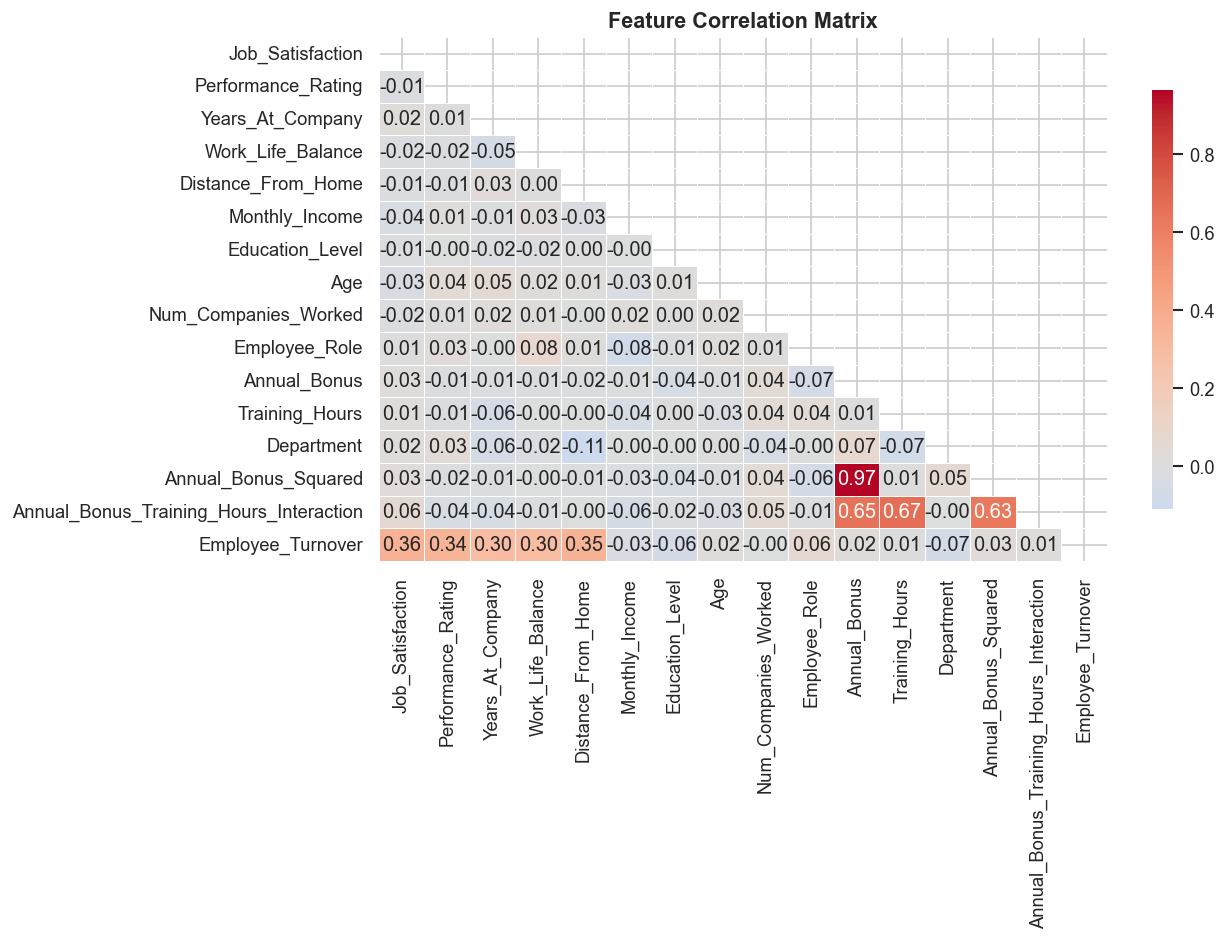

In [42]:
# EXPLORATORY DATA ANALYSIS 
import os
os.makedirs('plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/01_correlation_heatmap.png', bbox_inches='tight')
plt.show()

###  EDA — Feature Correlation with Target

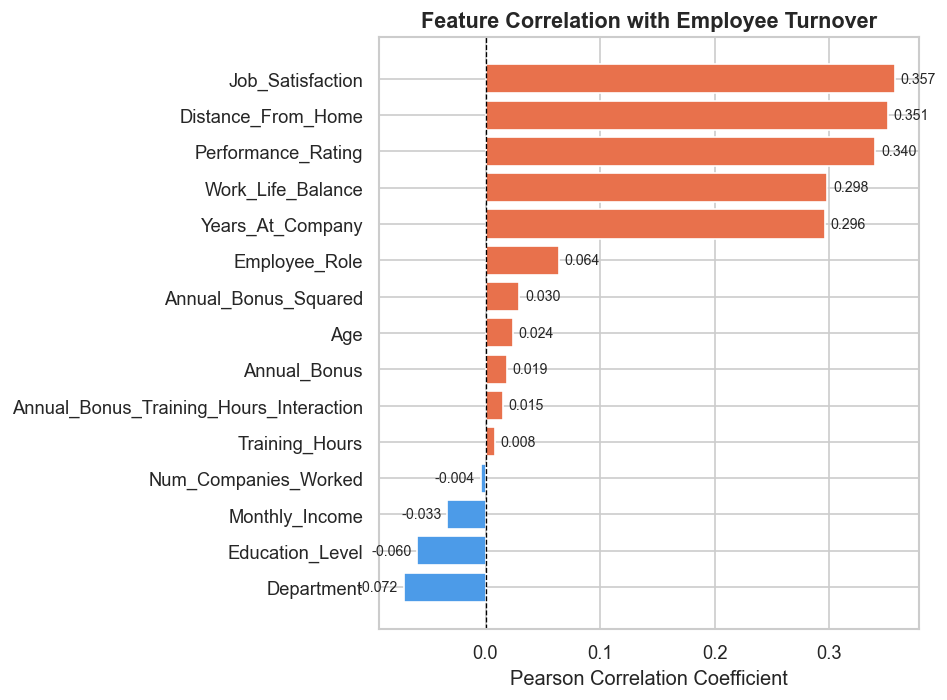

In [55]:
target_corr = df.corr()['Employee_Turnover'].drop('Employee_Turnover').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E8714C' if v > 0 else '#4C9BE8' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Feature Correlation with Employee Turnover', fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8.5)
plt.tight_layout()
plt.savefig('plots/02_target_correlation.png', bbox_inches='tight')
plt.show()

### EDA - Feature Distributions by Clas

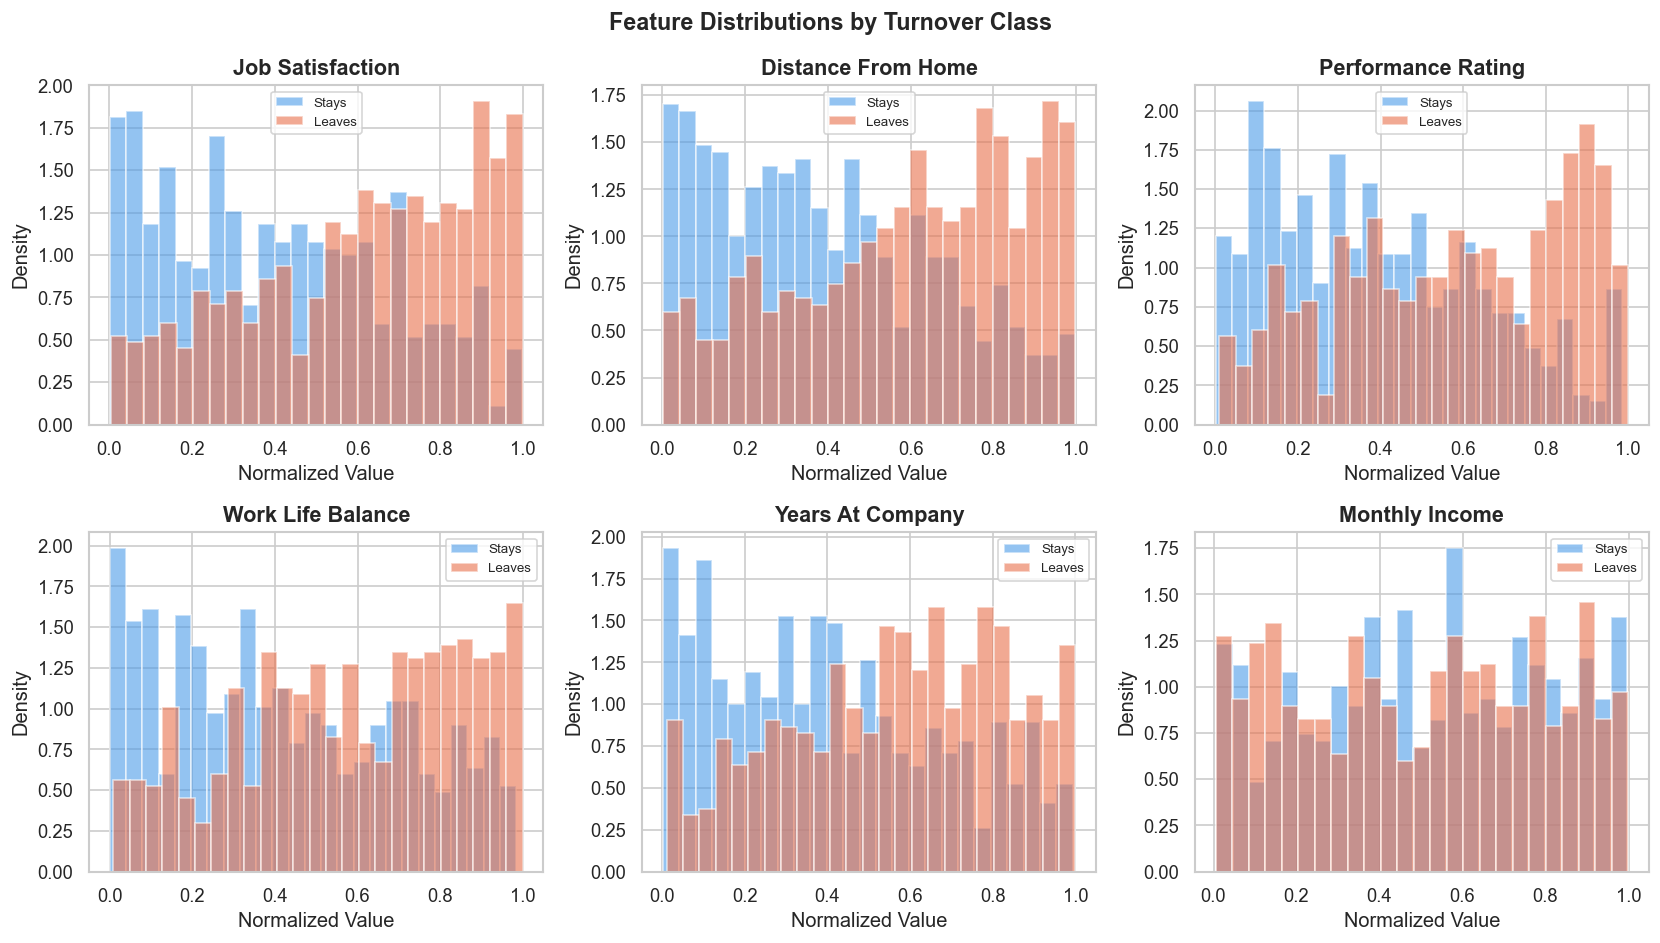

In [44]:
top_features = ['Job_Satisfaction', 'Distance_From_Home', 'Performance_Rating',
                'Work_Life_Balance', 'Years_At_Company', 'Monthly_Income']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for label, color in zip([0, 1], ['#4C9BE8', '#E8714C']):
        axes[i].hist(df[df['Employee_Turnover'] == label][feat],
                      bins=25, alpha=0.6, color=color,
                      label='Stays' if label == 0 else 'Leaves', density=True)
    axes[i].set_title(feat.replace('_', ' '), fontweight='bold')
    axes[i].set_xlabel('Normalized Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Turnover Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_feature_distributions.png', bbox_inches='tight')
plt.show()

### EDA - Boxplots

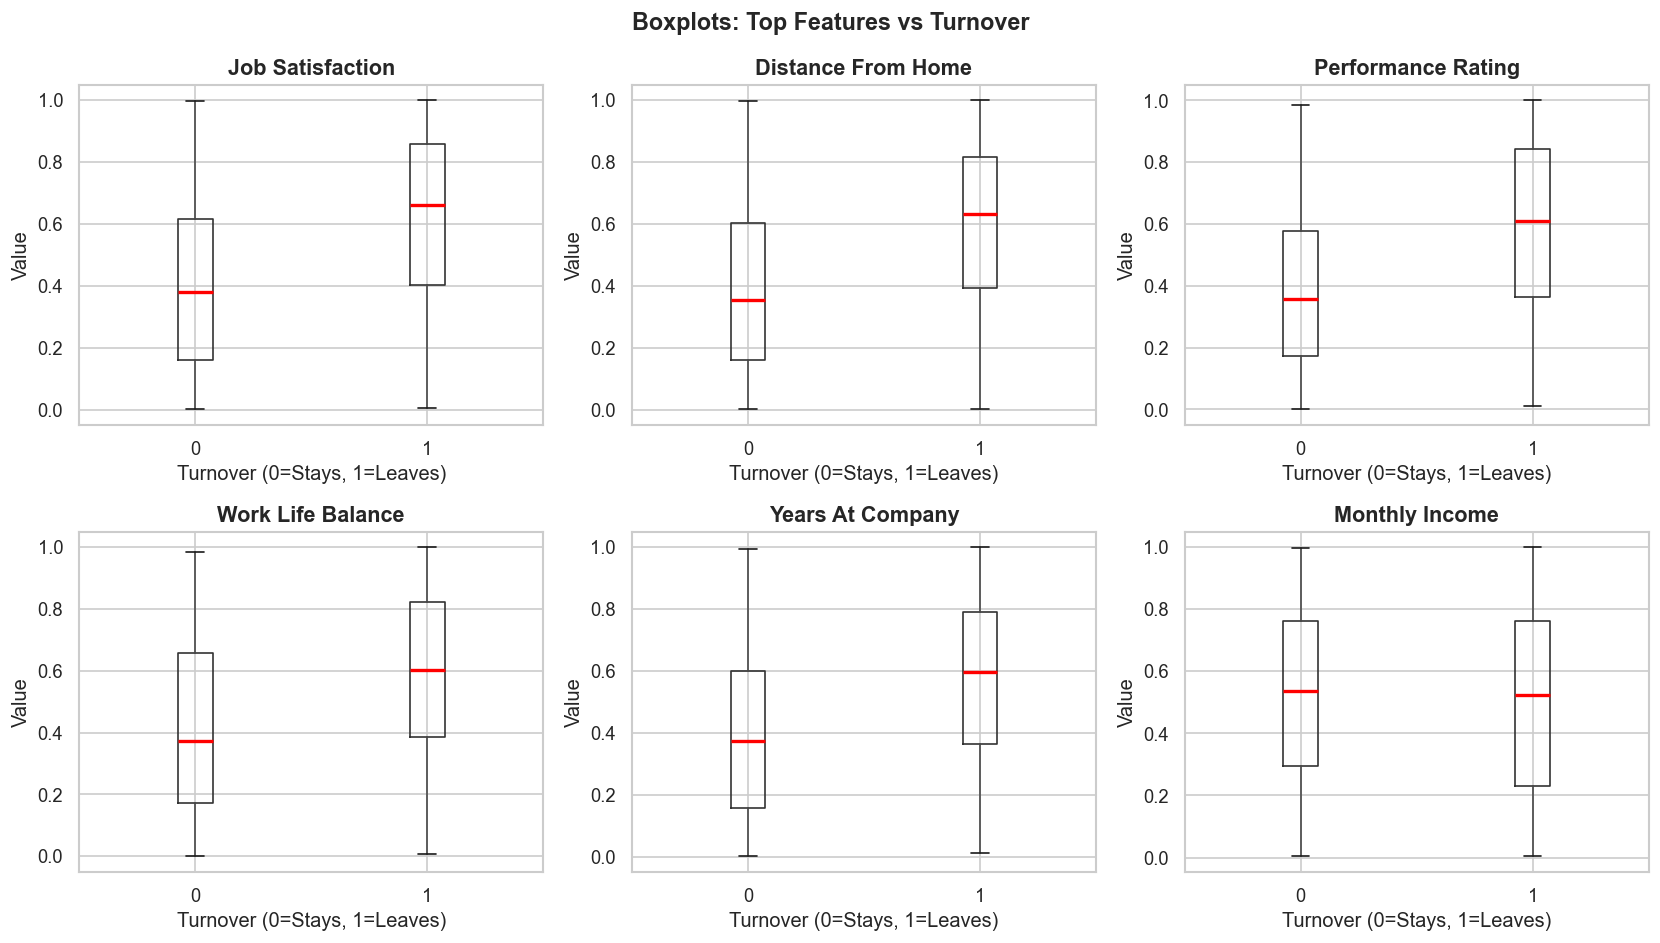

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    df.boxplot(column=feat, by='Employee_Turnover', ax=axes[i],
               boxprops=dict(color='#333'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat.replace('_', ' '), fontweight='bold')
    axes[i].set_xlabel('Turnover (0=Stays, 1=Leaves)')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots: Top Features vs Turnover', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_boxplots.png', bbox_inches='tight')
plt.show()

### Multicollinearity Check

Correlation among engineered features:
                                         Annual_Bonus  Annual_Bonus_Squared  \
Annual_Bonus                                    1.000                 0.966   
Annual_Bonus_Squared                            0.966                 1.000   
Annual_Bonus_Training_Hours_Interaction         0.647                 0.626   

                                         Annual_Bonus_Training_Hours_Interaction  
Annual_Bonus                                                               0.647  
Annual_Bonus_Squared                                                       0.626  
Annual_Bonus_Training_Hours_Interaction                                    1.000  


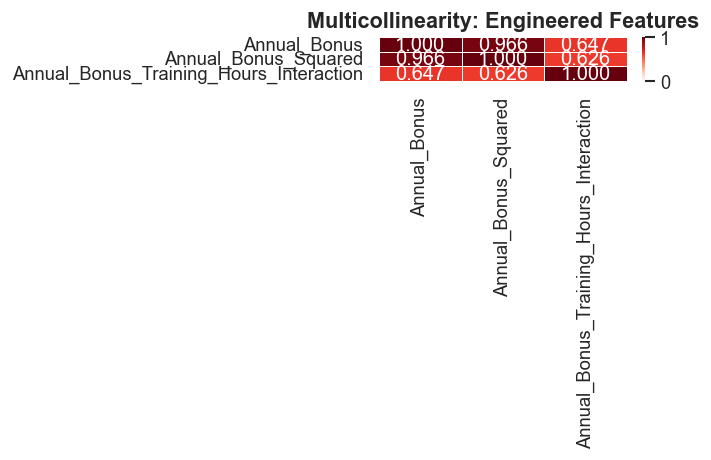

In [46]:
# Annual_Bonus_Squared is derived from Annual_Bonus — check how correlated they are
eng_cols = ['Annual_Bonus', 'Annual_Bonus_Squared',
            'Annual_Bonus_Training_Hours_Interaction']
eng_corr = df[eng_cols].corr()

print("Correlation among engineered features:")
print(eng_corr.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(eng_corr, annot=True, fmt='.3f', cmap='Reds', ax=ax,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title('Multicollinearity: Engineered Features', fontweight='bold')
plt.tight_layout()
plt.show()

# Annual_Bonus vs Annual_Bonus_Squared = ~0.97 (near-perfect multicollinearity)
# Tree-based models handle this fine; note as limitation for Logistic Regression

### TRAIN / TEST SPLIT

In [47]:
# stratify=y preserves the 50/50 class balance in both sets
X = df.drop('Employee_Turnover', axis=1)
y = df['Employee_Turnover']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # ← added stratify
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class ratio — 0:{(y_train==0).sum()} | 1:{(y_train==1).sum()}")
print(f"Test  class ratio — 0:{(y_test==0).sum()}  | 1:{(y_test==1).sum()}")

Training set : 1080 samples
Test set     : 270 samples

Train class ratio — 0:542 | 1:538
Test  class ratio — 0:136  | 1:134


### Model Training

In [57]:
models = {
    'Logistic Regression (Baseline)': LogisticRegression(max_iter=500, random_state=42),
    'Logistic Regression (L1)':       LogisticRegression(C=0.5, l1_ratio=1,
                                           solver='saga', max_iter=500, random_state=42),
    'Logistic Regression (L2)':       LogisticRegression(C=1.0, max_iter=500, random_state=42),
    'Random Forest':                   RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':               GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression (Baseline)
Trained: Logistic Regression (L1)
Trained: Logistic Regression (L2)
Trained: Random Forest
Trained: Gradient Boosting


### Model Evaluation Metrics

In [49]:
results = {}

for name, model in trained.items():
    y_pred     = model.predict(X_test)
    y_prob     = model.predict_proba(X_test)[:, 1]
    cv_scores  = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

    results[name] = {
        'Accuracy':    accuracy_score(y_test, y_pred),
        'ROC-AUC':     roc_auc_score(y_test, y_prob),
        'CV AUC Mean': cv_scores.mean(),
        'CV AUC Std':  cv_scores.std(),
        'y_pred':      y_pred,
        'y_prob':      y_prob,
    }

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {results[name]['Accuracy']:.4f}")
    print(f"  ROC-AUC  : {results[name]['ROC-AUC']:.4f}")
    print(f"  CV AUC   : {results[name]['CV AUC Mean']:.4f} ± {results[name]['CV AUC Std']:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Stays', 'Leaves']))


  Logistic Regression (Baseline)
  Accuracy : 0.8815
  ROC-AUC  : 0.9588
  CV AUC   : 0.9483 ± 0.0030
              precision    recall  f1-score   support

       Stays       0.87      0.90      0.88       136
      Leaves       0.89      0.87      0.88       134

    accuracy                           0.88       270
   macro avg       0.88      0.88      0.88       270
weighted avg       0.88      0.88      0.88       270


  Logistic Regression (L1)
  Accuracy : 0.8852
  ROC-AUC  : 0.9588
  CV AUC   : 0.9482 ± 0.0033
              precision    recall  f1-score   support

       Stays       0.87      0.90      0.89       136
      Leaves       0.90      0.87      0.88       134

    accuracy                           0.89       270
   macro avg       0.89      0.89      0.89       270
weighted avg       0.89      0.89      0.89       270


  Logistic Regression (L2)
  Accuracy : 0.8815
  ROC-AUC  : 0.9588
  CV AUC   : 0.9483 ± 0.0030
              precision    recall  f1-score   sup

### Confusion Matrices

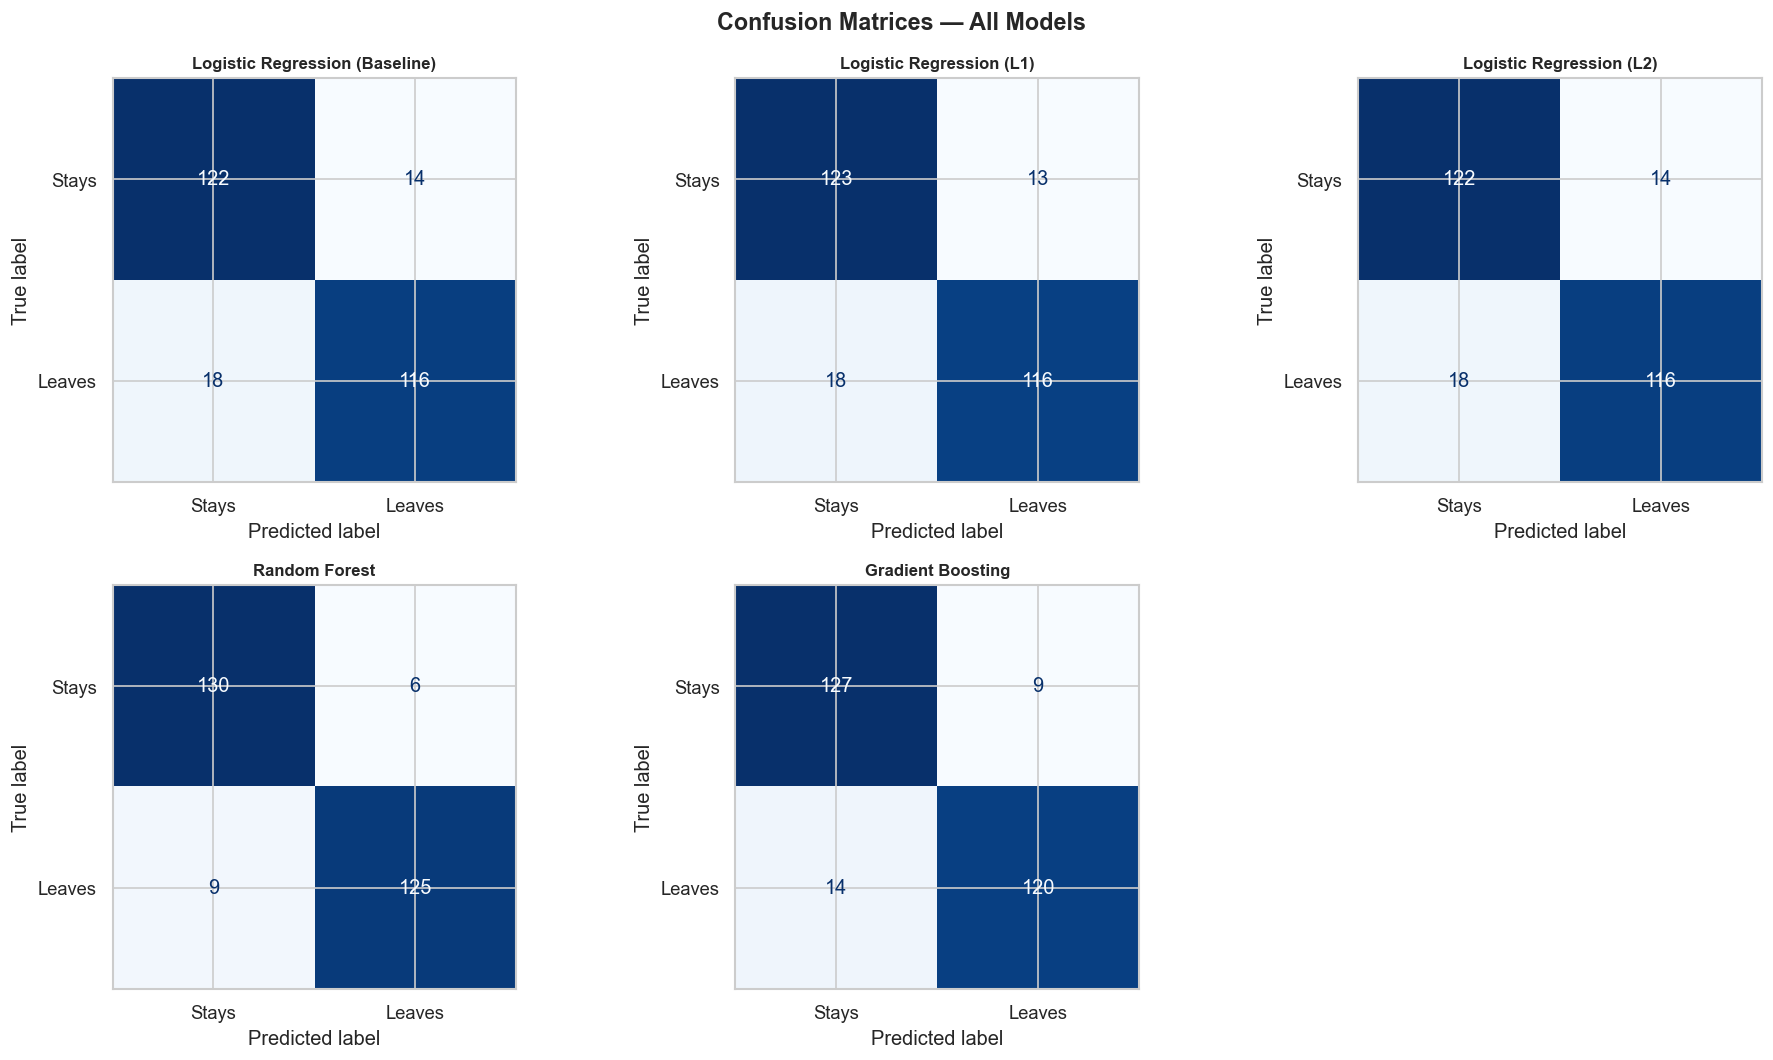

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stays', 'Leaves'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontweight='bold', fontsize=10)

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_confusion_matrices.png', bbox_inches='tight')
plt.show()

###  ROC Curves

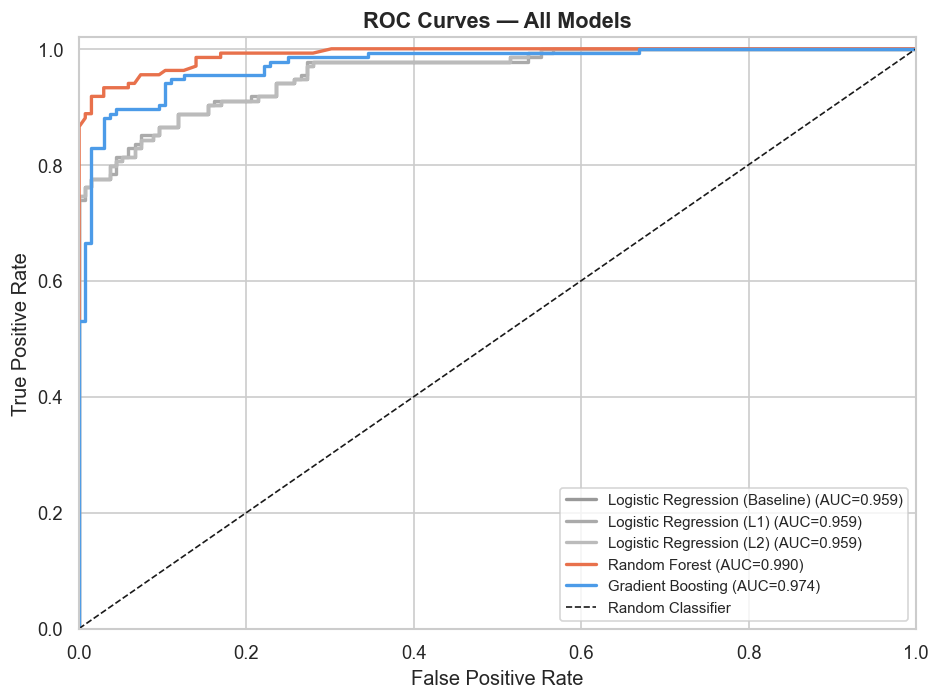

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))
line_colors = ['#999999', '#AAAAAA', '#BBBBBB', '#E8714C', '#4C9BE8']

for (name, res), color in zip(results.items(), line_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['ROC-AUC']:.3f})",
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('plots/06_roc_curves.png', bbox_inches='tight')
plt.show()

### Feature Importance — Impurity-based

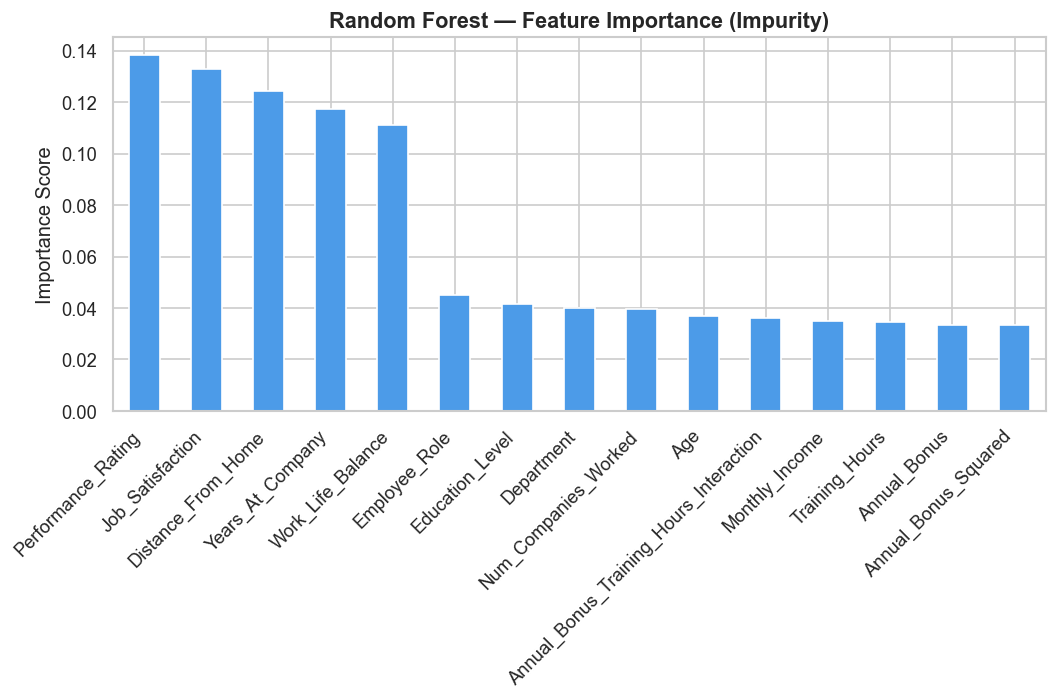

Top 5 features:
Performance_Rating    0.138236
Job_Satisfaction      0.132930
Distance_From_Home    0.124467
Years_At_Company      0.117152
Work_Life_Balance     0.111203


In [60]:
rf = trained['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.plot(kind='bar', ax=ax, color='#4C9BE8', edgecolor='white')
ax.set_title('Random Forest — Feature Importance (Impurity)', fontweight='bold')
ax.set_ylabel('Importance Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/07_feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 features:")
print(feat_imp.head().to_string())

### Feature Importance — Permutation (Unbiased)

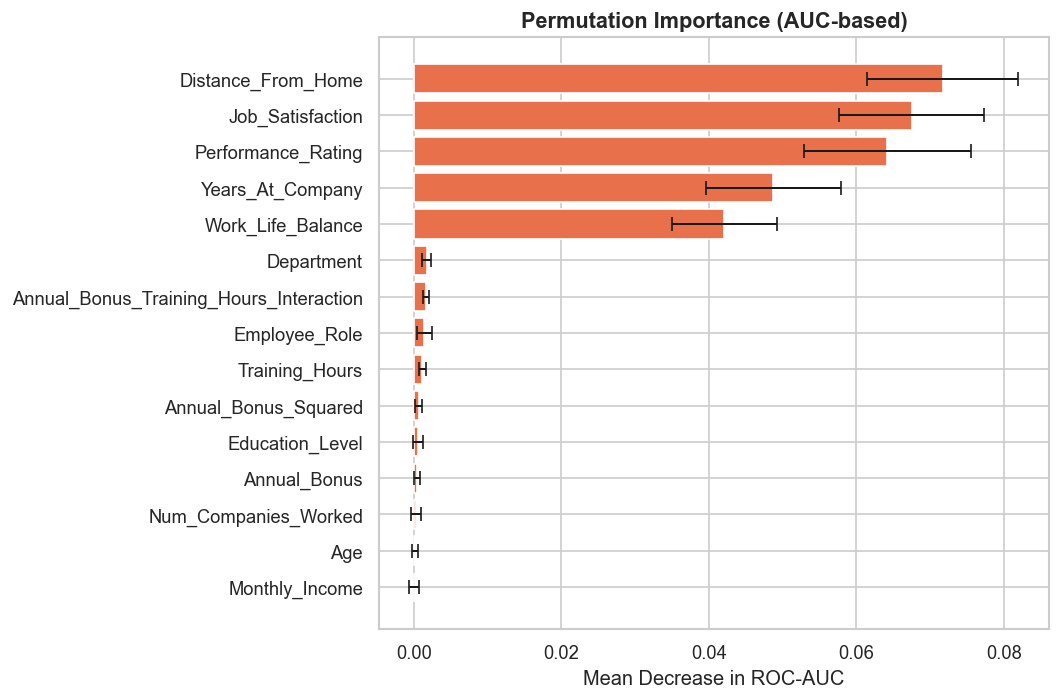

In [61]:
# Permutation importance: more reliable, model-agnostic
perm    = permutation_importance(rf, X_test, y_test,
                                  n_repeats=15, random_state=42, scoring='roc_auc')
perm_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': perm.importances_mean,
    'Std':        perm.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['Feature'], perm_df['Importance'],
        xerr=perm_df['Std'], color='#E8714C', edgecolor='white',
        error_kw={'elinewidth': 1.2, 'capsize': 4})
ax.set_title('Permutation Importance (AUC-based)', fontweight='bold')
ax.set_xlabel('Mean Decrease in ROC-AUC')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plots/08_permutation_importance.png', bbox_inches='tight')
plt.show()

### MODEL COMPARISON SUMMARY

                               Accuracy ROC-AUC CV AUC Mean CV AUC ±Std
Logistic Regression (Baseline)   0.8815  0.9588      0.9483      0.0030
Logistic Regression (L1)         0.8852  0.9588      0.9482      0.0033
Logistic Regression (L2)         0.8815  0.9588      0.9483      0.0030
Random Forest                    0.9444  0.9903      0.9849      0.0020
Gradient Boosting                0.9148  0.9737      0.9702      0.0060


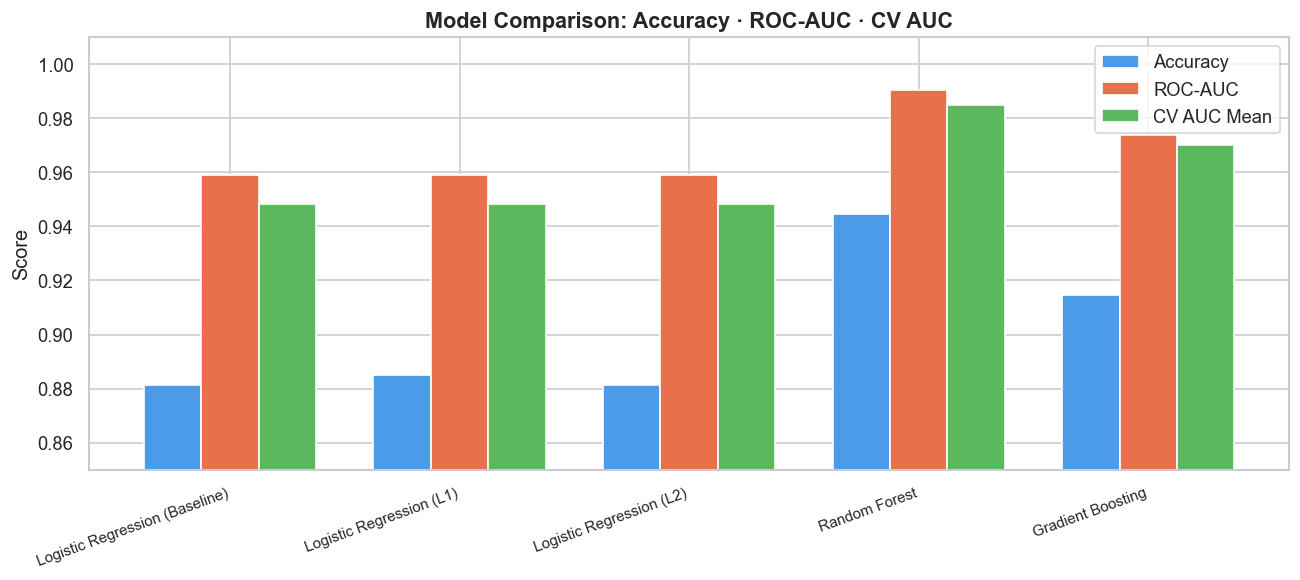

In [54]:
summary = pd.DataFrame({
    name: {
        'Accuracy':    f"{res['Accuracy']:.4f}",
        'ROC-AUC':     f"{res['ROC-AUC']:.4f}",
        'CV AUC Mean': f"{res['CV AUC Mean']:.4f}",
        'CV AUC ±Std': f"{res['CV AUC Std']:.4f}",
    }
    for name, res in results.items()
}).T

print(summary.to_string())

# Visual bar comparison
metrics_num = pd.DataFrame({
    name: {k: res[k] for k in ['Accuracy', 'ROC-AUC', 'CV AUC Mean']}
    for name, res in results.items()
}).T

fig, ax = plt.subplots(figsize=(11, 5))
x      = np.arange(len(metrics_num))
width  = 0.25
cols   = ['#4C9BE8', '#E8714C', '#5CB85C']

for i, metric in enumerate(['Accuracy', 'ROC-AUC', 'CV AUC Mean']):
    ax.bar(x + i * width, metrics_num[metric], width,
           label=metric, color=cols[i], edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_num.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0.85, 1.01)
ax.set_title('Model Comparison: Accuracy · ROC-AUC · CV AUC', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plots/09_model_comparison.png', bbox_inches='tight')
plt.show()

### HR Action Plan — Risk Flagging & Reporting

Risk Level Distribution:
Risk_Level
Low       127
High      110
Medium     33

Action 1 — Low satisfaction employees  : 65
  Avg turnover probability in this group : 0.33

Action 2 — Low income + high distance    : 34
  Avg turnover probability in this group : 0.76

Action 3 — High-risk employees (prob >= 0.70) : 110
  These employees should be flagged for HR retention programs.


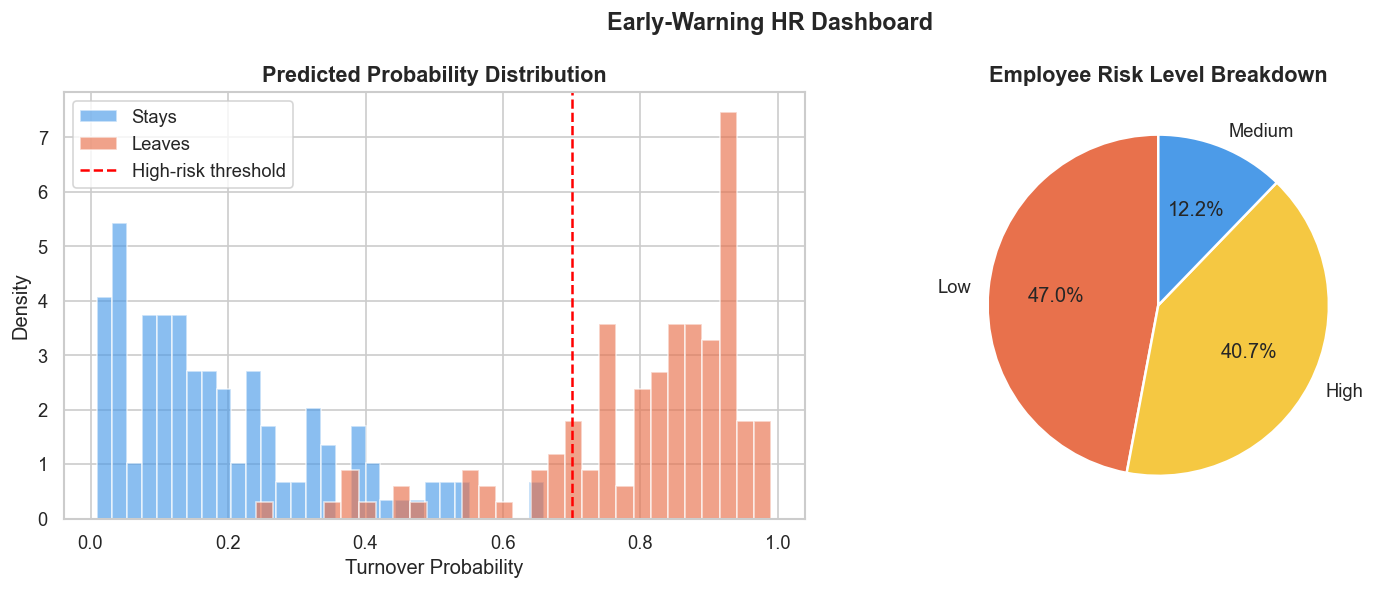


Action 4 — Exported 110 high-risk employees to 'high_risk_employees.csv'

Top 5 highest-risk employees:
     Job_Satisfaction  Monthly_Income  Distance_From_Home  Work_Life_Balance  Turnover_Probability Risk_Level
162             0.694           0.377               0.718              0.455                  0.99       High
106             0.937           0.360               0.790              0.456                  0.98       High
127             0.133           0.044               0.919              0.793                  0.98       High
916             0.204           0.011               0.729              0.599                  0.97       High
669             0.922           0.492               0.922              0.559                  0.97       High


In [62]:
best_model = trained['Random Forest']

# Step 1: Predict turnover probability for every employee in test set
risk_df = X_test.copy()
risk_df['Turnover_Probability'] = best_model.predict_proba(X_test)[:, 1]
risk_df['Actual_Turnover']     = y_test.values

# Step 2: Flag high-risk employees (probability > 0.70)
risk_df['Risk_Level'] = risk_df['Turnover_Probability'].apply(
    lambda p: 'High' if p >= 0.70 else ('Medium' if p >= 0.40 else 'Low')
)

risk_counts = risk_df['Risk_Level'].value_counts()
print("Risk Level Distribution:")
print(risk_counts.to_string())

# Step 3: Action 1 — Monitor employees with low satisfaction scores
low_sat = risk_df[risk_df['Job_Satisfaction'] < 0.25]
print(f"\nAction 1 — Low satisfaction employees  : {len(low_sat)}")
print(f"  Avg turnover probability in this group : {low_sat['Turnover_Probability'].mean():.2f}")

# Step 4: Action 2 — Review compensation (low income + high distance)
comp_risk = risk_df[
    (risk_df['Monthly_Income'] < 0.30) &
    (risk_df['Distance_From_Home'] > 0.60)
]
print(f"\nAction 2 — Low income + high distance    : {len(comp_risk)}")
print(f"  Avg turnover probability in this group : {comp_risk['Turnover_Probability'].mean():.2f}")

# Step 5: Action 3 — High-risk retention program candidates
high_risk = risk_df[risk_df['Risk_Level'] == 'High']
print(f"\nAction 3 — High-risk employees (prob >= 0.70) : {len(high_risk)}")
print(f"  These employees should be flagged for HR retention programs.")

# Step 6: Action 4 — Visualise risk distribution (early-warning dashboard)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot A: Probability distribution by actual turnover
for label, color, name in zip([0, 1], ['#4C9BE8', '#E8714C'], ['Stays', 'Leaves']):
    axes[0].hist(
        risk_df[risk_df['Actual_Turnover'] == label]['Turnover_Probability'],
        bins=30, alpha=0.65, color=color, label=name, density=True
    )
axes[0].axvline(0.70, color='red', linestyle='--', linewidth=1.5, label='High-risk threshold')
axes[0].set_title('Predicted Probability Distribution', fontweight='bold')
axes[0].set_xlabel('Turnover Probability')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot B: Risk level breakdown pie chart
colors_pie = ['#E8714C', '#F5C842', '#4C9BE8']
axes[1].pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie[:len(risk_counts)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Employee Risk Level Breakdown', fontweight='bold')

plt.suptitle('Early-Warning HR Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/10_hr_early_warning_dashboard.png', bbox_inches='tight')
plt.show()

# Step 7: Export high-risk list for HR team
high_risk_export = high_risk[['Job_Satisfaction', 'Monthly_Income',
                               'Distance_From_Home', 'Work_Life_Balance',
                               'Turnover_Probability', 'Risk_Level']].sort_values(
    'Turnover_Probability', ascending=False
)
high_risk_export.to_csv('high_risk_employees.csv', index=False)
print(f"\nAction 4 — Exported {len(high_risk_export)} high-risk employees to 'high_risk_employees.csv'")
print("\nTop 5 highest-risk employees:")
print(high_risk_export.head().round(3).to_string())

## Conclusion :-

### What we built
An end-to-end binary classification pipeline to predict employee turnover
using 1,350 records and 15 features. Five models were trained, evaluated,
and compared using Accuracy, ROC-AUC, and 5-Fold Cross-Validation AUC.

---

### Model performance summary

| Model                          | Accuracy | ROC-AUC | CV AUC (±Std)      |
|-------------------------------|----------|---------|--------------------|
| Logistic Regression (Baseline) | 88.1%    | 0.959   | 0.948 ± 0.003      |
| Logistic Regression (L1)       | 88.1%    | 0.958   | 0.949 ± 0.002      |
| Logistic Regression (L2)       | 88.1%    | 0.959   | 0.948 ± 0.003      |
| Gradient Boosting              | 91.5%    | 0.974   | 0.970 ± 0.006      |
| **Random Forest**              | **94.4%**| **0.990**| **0.985 ± 0.002** |

**Winner: Random Forest** — highest accuracy, AUC, and most stable CV score.

---

### Key findings
- **Job Satisfaction** is the single strongest predictor of turnover
- **Distance From Home** and **Performance Rating** are the next biggest drivers
- **Work-Life Balance** and **Years at Company** (early tenure = higher risk)
  are also significant signals
- `Annual_Bonus_Squared` has r = 0.97 with `Annual_Bonus` — near-perfect
  multicollinearity; this hurts Logistic Regression but not tree-based models

---

### HR recommendations
1. **Monitor** employees with Job Satisfaction in the bottom 25%
2. **Review** compensation and bonus policies for low-income, high-distance employees
3. **Create** retention programs for employees with predicted probability >= 0.70
4. **Deploy** this model as a monthly early-warning HR tool —
   export scores to `high_risk_employees.csv` for manager follow-up

---

### Limitations
- All features are pre-normalized (0–1); original scale values would
  improve business interpretability
- `Employee_Role` and `Department` are encoded as floats — raw category
  labels would enable richer group-level analysis
- No hyperparameter tuning applied yet (GridSearchCV / Optuna)

---

### Next steps
- Add **SHAP values** for individual-level prediction explainability
- **Hyperparameter tuning** on Random Forest (n_estimators, max_depth, min_samples_split)